# EJERCICIO 2 Propio

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from random import randrange
import datetime
from scipy.stats import norm

# Cargar el dataset
df = pd.read_csv('cybersecurity_attacks.csv')

# Mostrar el total de eventos registrados
total_eventos = len(df)
print(f"Total de eventos registrados: {total_eventos}")

# Calcular el porcentaje de uso de los puertos
# Primero, verifiquemos los tipos de protocolo (puerto).
print (df)


Total de eventos registrados: 40000
                 Timestamp Source IP Address Destination IP Address  \
0      2023-05-30 06:33:58     103.216.15.12           84.9.164.252   
1      2020-08-26 07:08:30    78.199.217.198         66.191.137.154   
2      2022-11-13 08:23:25      63.79.210.48          198.219.82.17   
3      2023-07-02 10:38:46     163.42.196.10        101.228.192.255   
4      2023-07-16 13:11:07     71.166.185.76        189.243.174.238   
...                    ...               ...                    ...   
39995  2023-05-26 14:08:42      26.36.109.26         121.100.75.240   
39996  2023-03-27 00:38:27      17.21.163.81         196.108.134.78   
39997  2022-03-31 01:45:49     162.35.217.57            98.107.0.15   
39998  2023-09-22 18:32:38    208.72.233.205         173.79.112.252   
39999  2023-10-10 11:59:52     14.102.21.108           109.198.45.7   

       Source Port  Destination Port Protocol  Packet Length Packet Type  \
0            31225             1761

In [3]:

# 1. Eliminar filas duplicadas
df = df.drop_duplicates()
print("\nDespués de eliminar duplicados:")
print(df.head())


Después de eliminar duplicados:
             Timestamp Source IP Address Destination IP Address  Source Port  \
0  2023-05-30 06:33:58     103.216.15.12           84.9.164.252        31225   
1  2020-08-26 07:08:30    78.199.217.198         66.191.137.154        17245   
2  2022-11-13 08:23:25      63.79.210.48          198.219.82.17        16811   
3  2023-07-02 10:38:46     163.42.196.10        101.228.192.255        20018   
4  2023-07-16 13:11:07     71.166.185.76        189.243.174.238         6131   

   Destination Port Protocol  Packet Length Packet Type Traffic Type  \
0             17616     ICMP            503        Data         HTTP   
1             48166     ICMP           1174        Data         HTTP   
2             53600      UDP            306     Control         HTTP   
3             32534      UDP            385        Data         HTTP   
4             26646      TCP           1462        Data          DNS   

                                        Payload Data 

In [4]:
# 2. Manejar valores nulos
# a. Eliminar filas con valores nulos
df_sin_duplicados = df.drop_duplicates()
print("DataFrame sin registros duplicados:")
print(df_sin_duplicados)
print("\n")

DataFrame sin registros duplicados:
                 Timestamp Source IP Address Destination IP Address  \
0      2023-05-30 06:33:58     103.216.15.12           84.9.164.252   
1      2020-08-26 07:08:30    78.199.217.198         66.191.137.154   
2      2022-11-13 08:23:25      63.79.210.48          198.219.82.17   
3      2023-07-02 10:38:46     163.42.196.10        101.228.192.255   
4      2023-07-16 13:11:07     71.166.185.76        189.243.174.238   
...                    ...               ...                    ...   
39995  2023-05-26 14:08:42      26.36.109.26         121.100.75.240   
39996  2023-03-27 00:38:27      17.21.163.81         196.108.134.78   
39997  2022-03-31 01:45:49     162.35.217.57            98.107.0.15   
39998  2023-09-22 18:32:38    208.72.233.205         173.79.112.252   
39999  2023-10-10 11:59:52     14.102.21.108           109.198.45.7   

       Source Port  Destination Port Protocol  Packet Length Packet Type  \
0            31225             1761

### Se valida que nos da un Future Warning en los comando usados en clase por lo cual se procede a corregir

In [5]:
df['Source Port'].fillna('DESCONOCIDO', inplace=True)
df['Destination Port'].fillna('DESCONOCIDO', inplace=True)

/tmp/ipykernel_3752/2523758318.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Source Port'].fillna('DESCONOCIDO', inplace=True)
/tmp/ipykernel_3752/2523758318.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)',

### Se corrige el furute Warning con estos comandos 

In [6]:
df['Source Port'] = df['Source Port'].fillna('DESCONOCIDO')
df['Destination Port'] = df['Destination Port'].fillna('DESCONOCIDO')


### Se valida que el archivo no tiene errores pero de igual manera se aplica las correciones en caso de ingresar otros archivos que si lo tengan.

In [7]:
print(df)

                 Timestamp Source IP Address Destination IP Address  \
0      2023-05-30 06:33:58     103.216.15.12           84.9.164.252   
1      2020-08-26 07:08:30    78.199.217.198         66.191.137.154   
2      2022-11-13 08:23:25      63.79.210.48          198.219.82.17   
3      2023-07-02 10:38:46     163.42.196.10        101.228.192.255   
4      2023-07-16 13:11:07     71.166.185.76        189.243.174.238   
...                    ...               ...                    ...   
39995  2023-05-26 14:08:42      26.36.109.26         121.100.75.240   
39996  2023-03-27 00:38:27      17.21.163.81         196.108.134.78   
39997  2022-03-31 01:45:49     162.35.217.57            98.107.0.15   
39998  2023-09-22 18:32:38    208.72.233.205         173.79.112.252   
39999  2023-10-10 11:59:52     14.102.21.108           109.198.45.7   

       Source Port  Destination Port Protocol  Packet Length Packet Type  \
0            31225             17616     ICMP            503        Dat

In [9]:
df['Fecha'] = pd.to_datetime(df['Fecha'])

# Ordenar el DataFrame por la columna 'Fecha' de menor a mayor
df_ordenado = df.sort_values(by='Fecha')
print (df_ordenado)

KeyError: 'Fecha'

In [ ]:
# Separar la columna Timestamp en Fecha y Hora
df['Fecha'] = pd.to_datetime(df['Timestamp']).dt.date
df['Hora'] = pd.to_datetime(df['Timestamp']).dt.time
print(df_ordenado['Fecha'])
print(df_ordenado['Hora'])

39660   2020-01-01
21778   2020-01-01
5067    2020-01-01
21343   2020-01-01
26028   2020-01-01
           ...    
39100   2023-10-11
29107   2023-10-11
11677   2023-10-11
11371   2023-10-11
10029   2023-10-11
Name: Fecha, Length: 40000, dtype: datetime64[ns]
39660    06:37:14
21778    05:21:39
5067     18:19:28
21343    19:58:27
26028    03:02:42
           ...   
39100    00:10:22
29107    17:44:41
11677    19:34:23
11371    07:06:24
10029    02:12:56
Name: Hora, Length: 40000, dtype: object


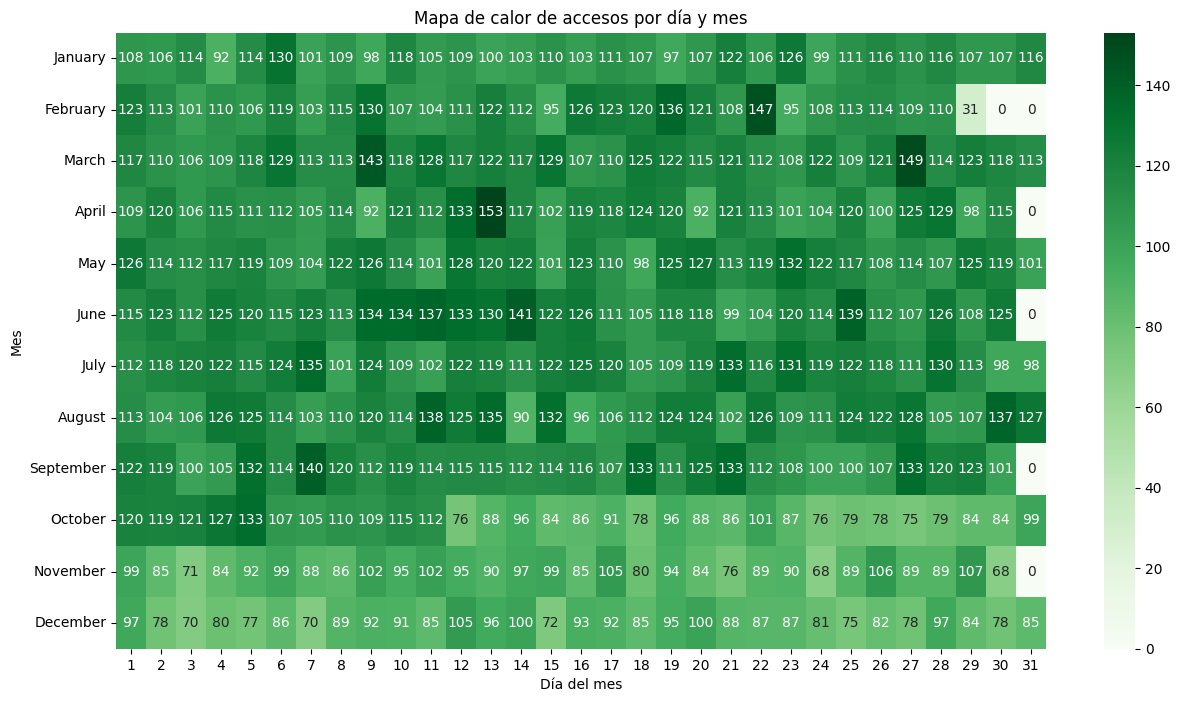

In [ ]:
# Convertir la columna 'fecha' a tipo datetime
df['fecha'] = pd.to_datetime(df_ordenado['Fecha'])

# Extraer el mes y el día
df['mes'] = df['fecha'].dt.month_name()  # Extraer el nombre del mes
df['dia'] = df['fecha'].dt.day          # Extraer el día del mes

# Crear una tabla pivote con la cantidad de accesos por mes y día
heatmap_data = df.pivot_table(index="mes", columns="dia", aggfunc="size", fill_value=0)

# Reordenar los meses en orden lógico
meses_ordenados = [
    "January", "February", "March", "April", "May", "June", 
    "July", "August", "September", "October", "November", "December"
]
heatmap_data = heatmap_data.reindex(meses_ordenados)

# Crear el mapa de calor
plt.figure(figsize=(15, 8))
sns.heatmap(heatmap_data, cmap="Greens", annot=True, fmt="d")

# Configurar etiquetas y título
plt.title("Mapa de calor de accesos por día y mes")
plt.xlabel("Día del mes")
plt.ylabel("Mes")

# Mostrar el gráfico
plt.show()

/tmp/ipykernel_7484/1042910834.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=traffic_counts.index, y=traffic_counts.values, palette="viridis")


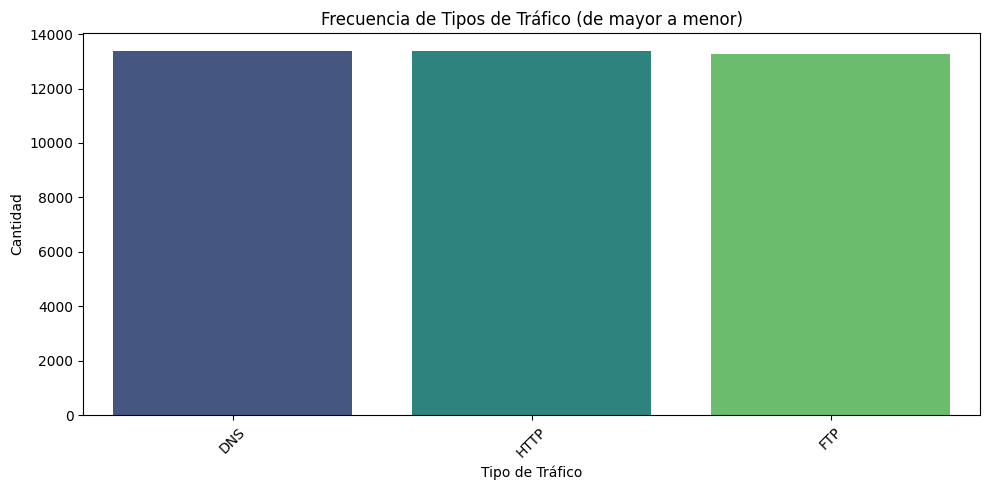

In [ ]:
# Contar la frecuencia de cada tipo de tráfico
traffic_counts = df['Traffic Type'].value_counts()

# Ordenar los valores de mayor a menor
traffic_counts = traffic_counts.sort_values(ascending=False)

# Crear el gráfico de barras
plt.figure(figsize=(10, 5))
sns.barplot(x=traffic_counts.index, y=traffic_counts.values, palette="viridis")

# Añadir etiquetas y título
plt.title("Frecuencia de Tipos de Tráfico (de mayor a menor)")
plt.xlabel("Tipo de Tráfico")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)  # Rotar las etiquetas del eje x para mejor legibilidad

# Mostrar el gráfico
plt.tight_layout()
plt.show()

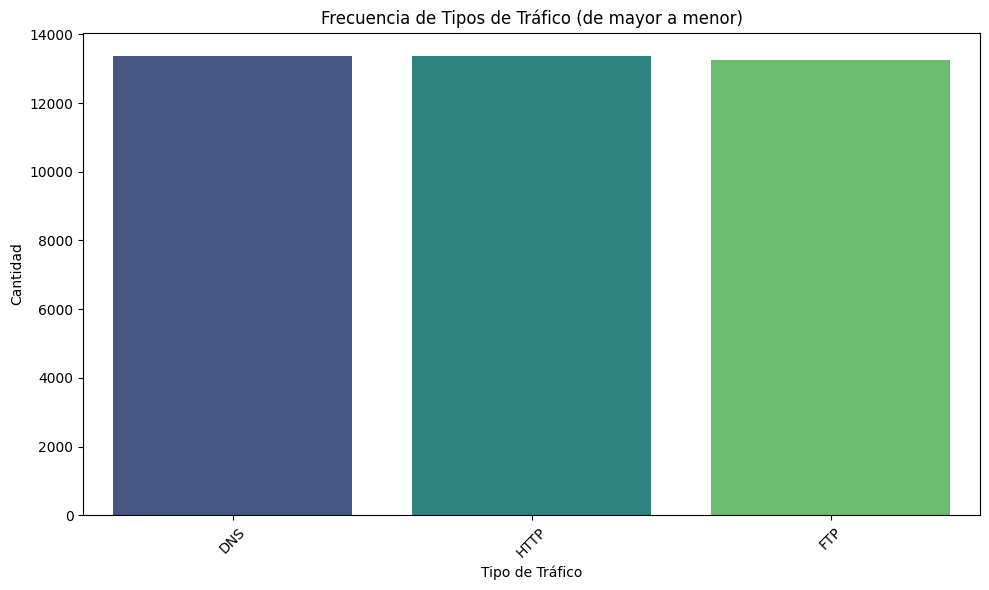

In [ ]:
traffic_counts = df['Traffic Type'].value_counts()

# Ordenar los valores de mayor a menor
traffic_counts = traffic_counts.sort_values(ascending=False)

# Crear el gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(x=traffic_counts.index, y=traffic_counts.values, hue=traffic_counts.index, palette="viridis", legend=False)

# Añadir etiquetas y título
plt.title("Frecuencia de Tipos de Tráfico (de mayor a menor)")
plt.xlabel("Tipo de Tráfico")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)  # Rotar las etiquetas del eje x para mejor legibilidad

# Mostrar el gráfico
plt.tight_layout()
plt.show()

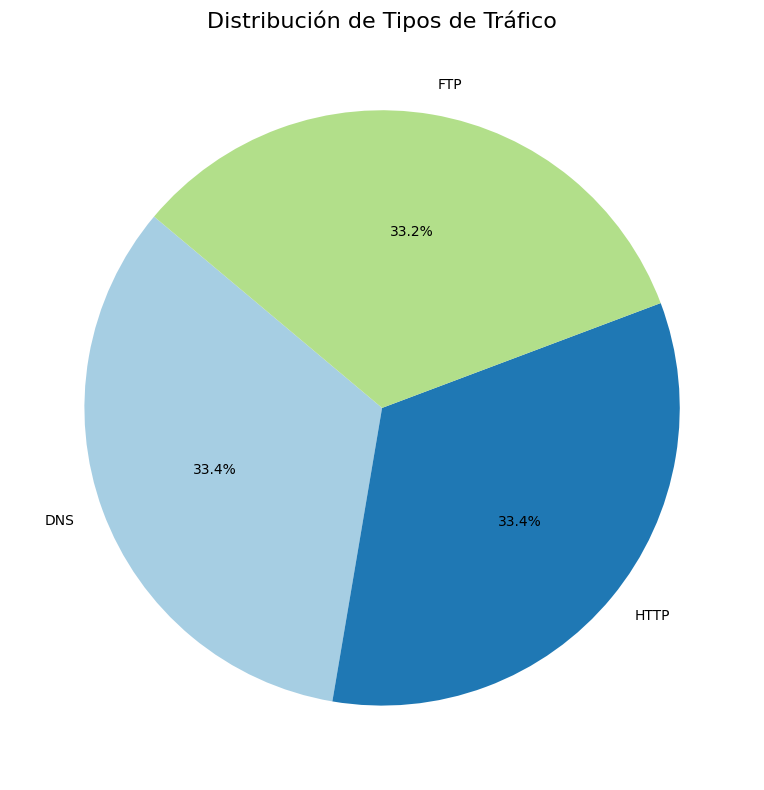

In [ ]:
traffic_counts = df['Traffic Type'].value_counts()

# Crear el gráfico de pastel
plt.figure(figsize=(12, 8))  # Tamaño del gráfico
plt.pie(traffic_counts, labels=traffic_counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)

# Añadir título
plt.title("Distribución de Tipos de Tráfico", fontsize=16)

# Mostrar el gráfico
plt.tight_layout()  # Ajustar el layout para que no se corten las etiquetas
plt.show()

Media del tiempo de sesión: 792.75 segundos
Desviación estándar: 786.56 segundos


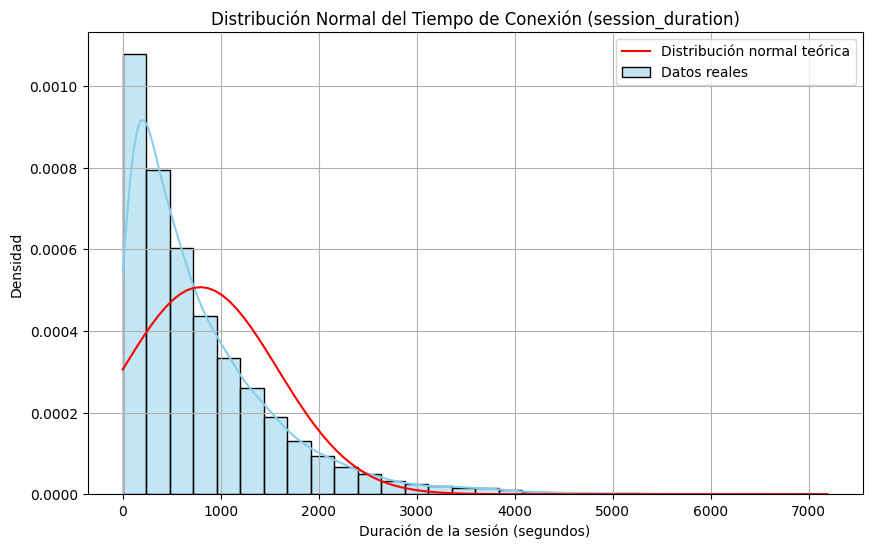

In [ ]:
df['session_duration'] = pd.to_numeric(df['session_duration'], errors='coerce')
df = df.dropna(subset=['session_duration'])  # Eliminar posibles valores nulos

# Calcular media y desviación estándar
media = df['session_duration'].mean()
desviacion = df['session_duration'].std()

print(f"Media del tiempo de sesión: {media:.2f} segundos")
print(f"Desviación estándar: {desviacion:.2f} segundos")

# Crear histograma con curva de distribución normal
plt.figure(figsize=(10, 6))
sns.histplot(df['session_duration'], kde=True, bins=30, stat="density", color="skyblue", label="Datos reales")

# Crear una curva de distribución normal teórica
x = np.linspace(df['session_duration'].min(), df['session_duration'].max(), 100)
y = norm.pdf(x, media, desviacion)
plt.plot(x, y, 'r', label="Distribución normal teórica")

# Configuración del gráfico
plt.title("Distribución Normal del Tiempo de Conexión (session_duration)")
plt.xlabel("Duración de la sesión (segundos)")
plt.ylabel("Densidad")
plt.legend()
plt.grid(True)

# Mostrar el gráfico
plt.show()

In [ ]:
df['ip_segura'] = df['ip_reputation_score'] > 0.5

# Crear tabla de resumen
resumen_ips = df.groupby('ip_segura').agg(
    intentos_fallidos=('failed_logins', 'sum'),
    total_sesiones=('session_id', 'count')
).reset_index()

# Renombrar valores para claridad
resumen_ips['ip_segura'] = resumen_ips['ip_segura'].map({True: "Segura (>0.5)", False: "No Segura (≤0.5)"})

# Mostrar tabla
print(resumen_ips)

          ip_segura  intentos_fallidos  total_sesiones
0  No Segura (≤0.5)              11729            7763
1     Segura (>0.5)               2746            1774


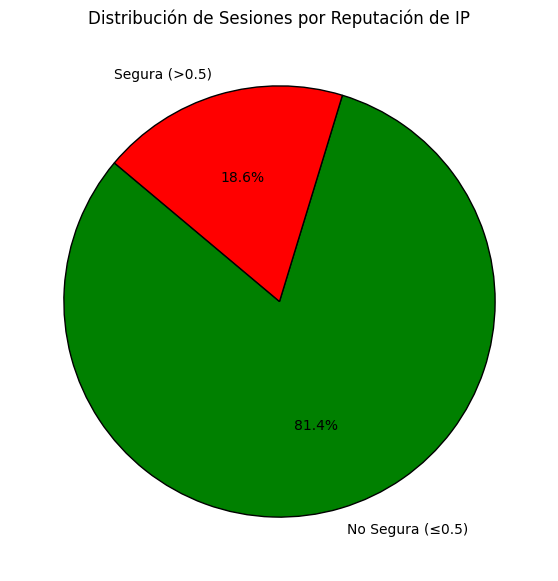

In [ ]:
labels = resumen_ips['ip_segura']
sizes = resumen_ips['total_sesiones']
colors = ["green", "red"]  # Verde para seguras, rojo para no seguras

# Crear el gráfico de pastel
plt.figure(figsize=(7, 7))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=140, wedgeprops={'edgecolor': 'black'})

# Configuración del gráfico
plt.title("Distribución de Sesiones por Reputación de IP")
plt.show()

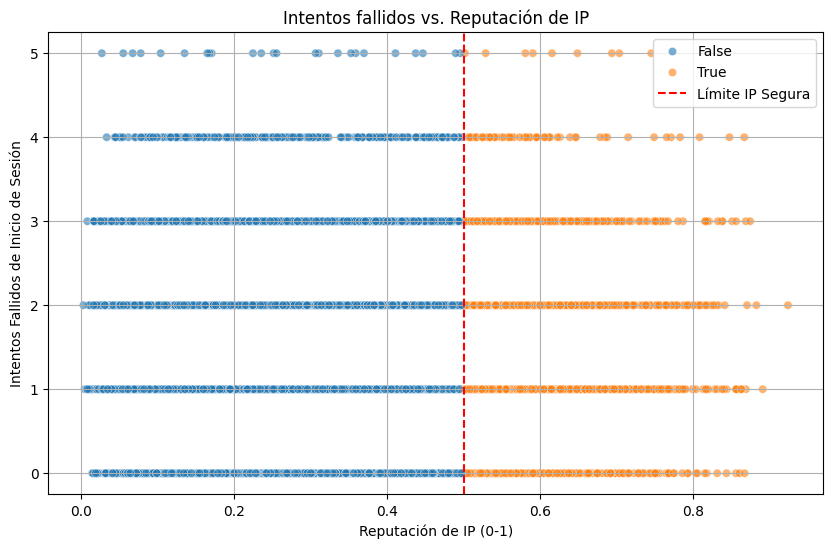

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="ip_reputation_score", y="failed_logins", alpha=0.6, hue="ip_segura")

# Configurar etiquetas y título
plt.title("Intentos fallidos vs. Reputación de IP")
plt.xlabel("Reputación de IP (0-1)")
plt.ylabel("Intentos Fallidos de Inicio de Sesión")
plt.axvline(0.5, color="red", linestyle="--", label="Límite IP Segura")
plt.legend()
plt.grid(True)

# Mostrar el gráfico
plt.show()

/tmp/ipykernel_7484/2812898504.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=browser_counts.index, y=browser_counts.values, palette="coolwarm")


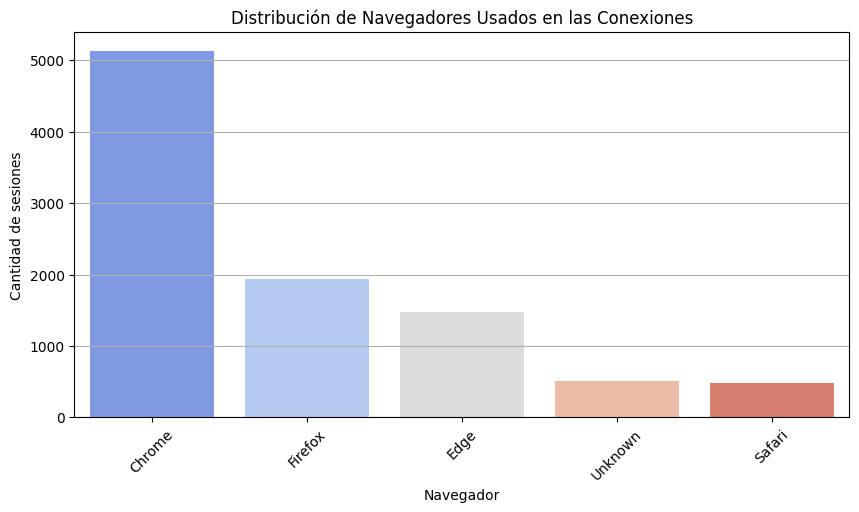

In [ ]:
# Contar la cantidad de sesiones por navegador
browser_counts = df["browser_type"].value_counts()

# Crear gráfico de barras
plt.figure(figsize=(10, 5))
sns.barplot(x=browser_counts.index, y=browser_counts.values, palette="coolwarm")

# Configurar etiquetas
plt.title("Distribución de Navegadores Usados en las Conexiones")
plt.xlabel("Navegador")
plt.ylabel("Cantidad de sesiones")
plt.xticks(rotation=45)  # Rotar etiquetas si son muchas
plt.grid(axis='y')

# Mostrar el gráfico
plt.show()

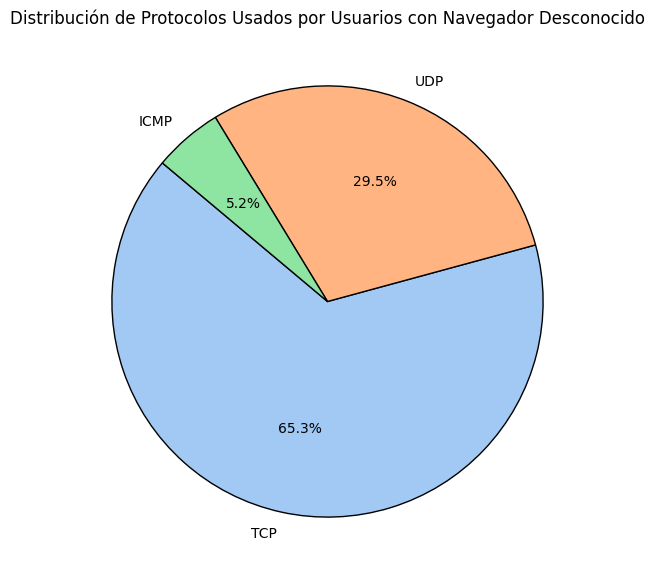

In [ ]:
# Filtrar solo los usuarios con navegador "Unknown"
df_unknown = df[df["browser_type"] == "Unknown"]

# Contar la cantidad de sesiones por protocolo
protocol_counts = df_unknown["protocol_type"].value_counts()

# Crear gráfico de pastel
plt.figure(figsize=(7, 7))
plt.pie(protocol_counts, labels=protocol_counts.index, autopct='%1.1f%%', 
        colors=sns.color_palette("pastel", len(protocol_counts)), startangle=140, wedgeprops={'edgecolor': 'black'})

# Configuración del gráfico
plt.title("Distribución de Protocolos Usados por Usuarios con Navegador Desconocido")
plt.show()